# Confidence Intervals: Statistical Inference & Estimation

## What is a Confidence Interval?

A **confidence interval (CI)** gives an estimated range of values which is likely to include an unknown population parameter, based on sample data.

> Instead of saying *"the population mean is exactly 5"*, we say *"we are 95% confident the population mean lies between 4.2 and 5.8"*.

### Key Ideas

| Concept | Description |
|--------|-------------|
| **Point Estimate** | A single value estimate (e.g., sample mean $\bar{x}$) |
| **Interval Estimate** | A range of plausible values for the parameter |
| **Confidence Level** | The probability that the interval contains the true parameter (e.g., 95%) |
| **Margin of Error** | The "fuzzy zone" around the point estimate |

### Formula for a Confidence Interval

$$\text{CI} = \text{Point Estimate} \pm \text{Margin of Error}$$

For a population mean with known standard deviation:

$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

For a population mean with unknown standard deviation:

$$\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")


Libraries loaded successfully!
NumPy version: 2.4.3
SciPy version: 1.17.1


## 1. Sampling Distribution & the Central Limit Theorem

Before building confidence intervals, we need to understand the **sampling distribution of the sample mean**.

> **Central Limit Theorem (CLT):** Regardless of the population distribution, the sampling distribution of $\bar{x}$ approaches $N(\mu, \sigma/\sqrt{n})$ as $n$ increases.

Let's visualize this by drawing many samples from a skewed distribution.

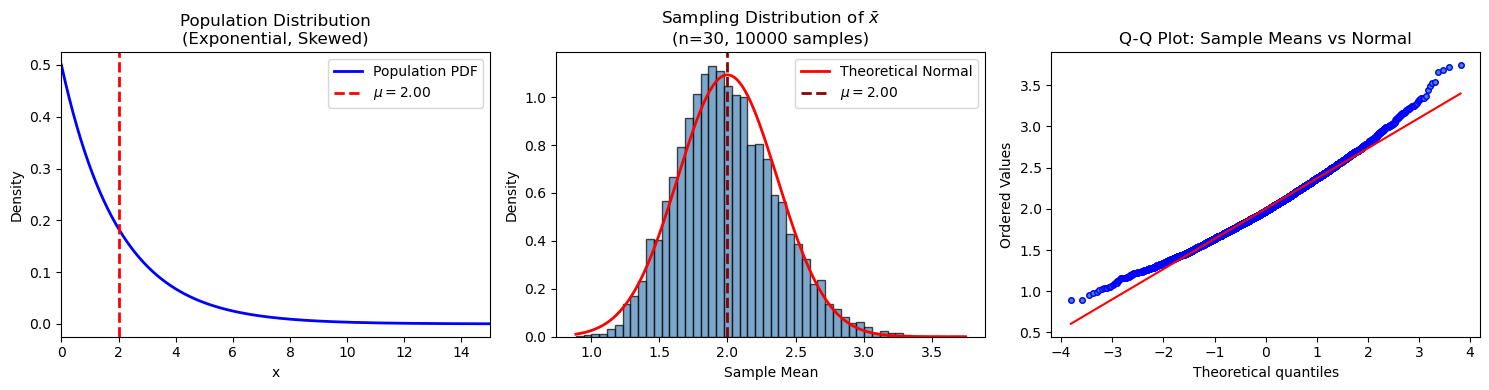

True population mean: 2.0000
Mean of sample means: 2.0023
True standard error: 0.3651
Std of sample means: 0.3685


In [2]:
# Population: Exponential distribution (highly skewed)
lambda_param = 0.5
population = stats.expon(scale=1/lambda_param)

# True population parameters
true_mean = population.mean()
true_std = population.std()

# Draw many samples and compute their means
n_samples = 10000
sample_size = 30

sample_means = np.array([np.mean(population.rvs(size=sample_size)) for _ in range(n_samples)])

# Theoretical sampling distribution parameters
theoretical_std = true_std / np.sqrt(sample_size)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Population distribution
x_pop = np.linspace(0, 15, 1000)
axes[0].plot(x_pop, population.pdf(x_pop), 'b-', lw=2, label='Population PDF')
axes[0].axvline(true_mean, color='r', linestyle='--', lw=2, label=rf'$\mu = {true_mean:.2f}$')
axes[0].set_title('Population Distribution\n(Exponential, Skewed)', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 15)

# Plot 2: Histogram of sample means (sampling distribution)
axes[1].hist(sample_means, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
x_samp = np.linspace(sample_means.min(), sample_means.max(), 1000)
axes[1].plot(x_samp, stats.norm.pdf(x_samp, loc=true_mean, scale=theoretical_std), 
             'r-', lw=2, label='Theoretical Normal')
axes[1].axvline(true_mean, color='darkred', linestyle='--', lw=2, label=rf'$\mu = {true_mean:.2f}$')
axes[1].set_title(f'Sampling Distribution of $\\bar{{x}}$\n(n={sample_size}, {n_samples} samples)', fontsize=12)
axes[1].set_xlabel('Sample Mean')
axes[1].set_ylabel('Density')
axes[1].legend()

# Plot 3: Q-Q plot to check normality
stats.probplot(sample_means, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Sample Means vs Normal', fontsize=12)
axes[2].get_lines()[0].set_markerfacecolor('steelblue')
axes[2].get_lines()[0].set_markersize(4)

plt.tight_layout()
plt.savefig('sampling_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True population mean: {true_mean:.4f}")
print(f"Mean of sample means: {np.mean(sample_means):.4f}")
print(f"True standard error: {theoretical_std:.4f}")
print(f"Std of sample means: {np.std(sample_means, ddof=1):.4f}")


## 2. Confidence Interval for the Mean ($\sigma$ Known)

When the population standard deviation $\sigma$ is known, we use the **Z-distribution**.

$$\text{CI} = \bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

### Interpretation
If we were to repeat our sampling process many times, approximately $(1-\alpha) \times 100\%$ of the computed intervals would contain the true population mean $\mu$.

Let's simulate this to see the "capture rate" in action.

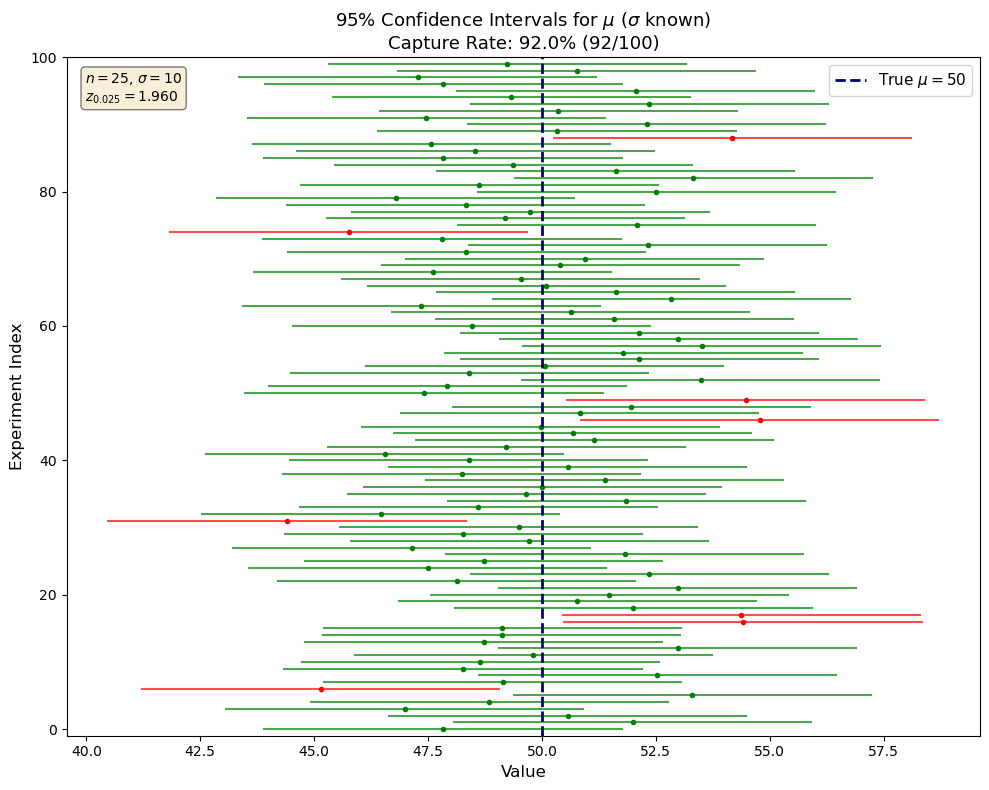

Z-critical value: 1.9600
Margin of Error: 3.9199
Capture rate: 92.00%


In [3]:
# Parameters
mu_true = 50
sigma_known = 10
n = 25
confidence_level = 0.95
alpha = 1 - confidence_level

# Critical z-value
z_critical = stats.norm.ppf(1 - alpha/2)

# Number of experiments
n_experiments = 100

# Generate sample means and CIs
np.random.seed(123)
sample_means_ci = np.random.normal(loc=mu_true, scale=sigma_known/np.sqrt(n), size=n_experiments)

# Calculate margins of error
margins = z_critical * (sigma_known / np.sqrt(n))

lower_bounds = sample_means_ci - margins
upper_bounds = sample_means_ci + margins

# Check which intervals capture the true mean
captures = (lower_bounds <= mu_true) & (upper_bounds >= mu_true)
capture_rate = np.mean(captures)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot each confidence interval
for i in range(n_experiments):
    color = 'green' if captures[i] else 'red'
    ax.plot([lower_bounds[i], upper_bounds[i]], [i, i], color=color, alpha=0.7, lw=1.5)
    ax.plot(sample_means_ci[i], i, 'o', color=color, markersize=3)

# True mean line
ax.axvline(mu_true, color='navy', linestyle='--', lw=2, label=rf'True $\mu = {mu_true}$')

# Formatting
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Experiment Index', fontsize=12)
ax.set_title(rf'{confidence_level*100:.0f}% Confidence Intervals for $\mu$ ($\sigma$ known)' + '\n' +
             rf'Capture Rate: {capture_rate*100:.1f}% ({np.sum(captures)}/{n_experiments})', fontsize=13)
ax.set_ylim(-1, n_experiments)
ax.legend(loc='upper right', fontsize=11)

# Add annotation
ax.text(0.02, 0.98, rf'$n = {n}$, $\sigma = {sigma_known}$' + '\n' +
        rf'$z_{{{(1-confidence_level)/2:.3f}}} = {z_critical:.3f}$',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('ci_mean_sigma_known.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Z-critical value: {z_critical:.4f}")
print(f"Margin of Error: {margins:.4f}")
print(f"Capture rate: {capture_rate*100:.2f}%")


## 3. Confidence Interval for the Mean ($\sigma$ Unknown) — The t-Distribution

In practice, $\sigma$ is almost never known. We estimate it with the sample standard deviation $s$ and use the **t-distribution**.

$$\text{CI} = \bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

### Why t instead of Z?

- The t-distribution has **heavier tails** than the normal distribution
- It accounts for the extra uncertainty from estimating $\sigma$ with $s$
- As $n \to \infty$, $t \to z$ (t-distribution converges to normal)

### Degrees of Freedom
The shape of the t-distribution depends on **degrees of freedom** ($df = n - 1$). With more data, we have more df and the distribution becomes narrower.


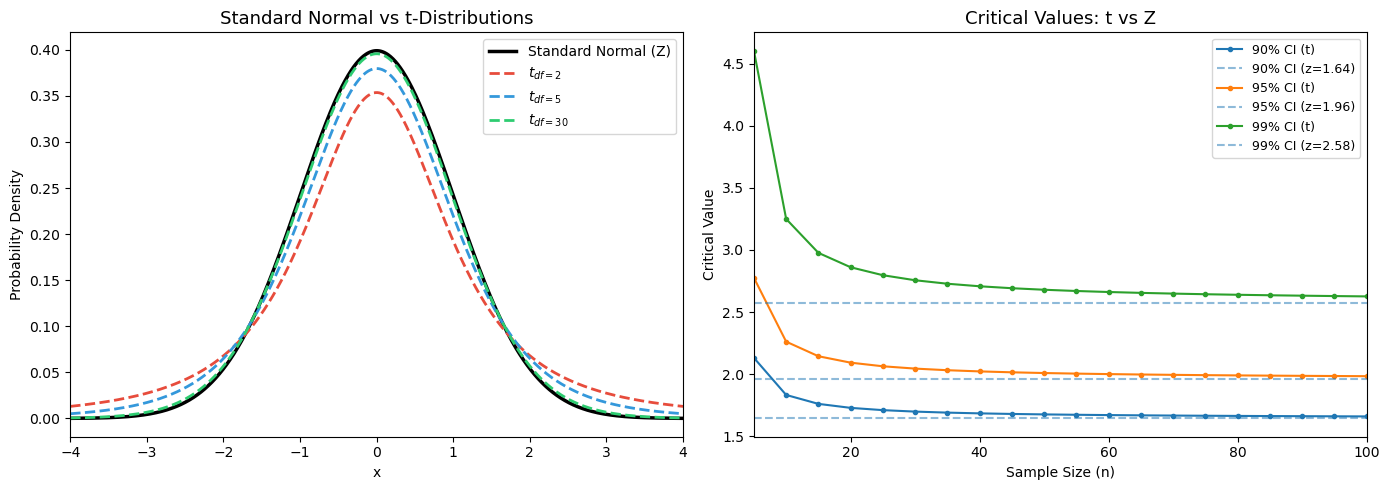

Sample mean: 98.438
Sample std: 12.768
t-critical (df=19): 2.0930
95% CI: [92.463, 104.414]


In [4]:
# Compare Z vs t distributions
x = np.linspace(-4, 4, 1000)
z_pdf = stats.norm.pdf(x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Z vs t distributions
axes[0].plot(x, z_pdf, 'k-', lw=2.5, label='Standard Normal (Z)')
colors = ['#e74c3c', '#3498db', '#2ecc71']
dfs = [2, 5, 30]

for df, color in zip(dfs, colors):
    t_pdf = stats.t.pdf(x, df)
    axes[0].plot(x, t_pdf, color=color, lw=2, linestyle='--', label=rf'$t_{{df={df}}}$')

axes[0].set_title('Standard Normal vs t-Distributions', fontsize=13)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
axes[0].legend(loc='upper right')
axes[0].set_xlim(-4, 4)

# Plot 2: Critical values comparison
confidence_levels = np.array([0.90, 0.95, 0.99])
sample_sizes = np.arange(5, 101, 5)

ax2 = axes[1]
for conf in confidence_levels:
    alpha_val = 1 - conf
    z_crit = stats.norm.ppf(1 - alpha_val/2)
    t_crits = [stats.t.ppf(1 - alpha_val/2, df=n-1) for n in sample_sizes]
    
    ax2.plot(sample_sizes, t_crits, '-o', markersize=3, label=rf'{conf*100:.0f}% CI (t)')
    ax2.axhline(z_crit, linestyle='--', alpha=0.5, label=rf'{conf*100:.0f}% CI (z={z_crit:.2f})')

# Remove duplicate z labels
handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)

ax2.set_title('Critical Values: t vs Z', fontsize=13)
ax2.set_xlabel('Sample Size (n)')
ax2.set_ylabel('Critical Value')
ax2.set_xlim(5, 100)

plt.tight_layout()
plt.savefig('t_vs_z_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Demonstrate a single t-based CI
np.random.seed(7)
sample_data = np.random.normal(loc=100, scale=15, size=20)
n_obs = len(sample_data)
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)

t_crit = stats.t.ppf(0.975, df=n_obs-1)
margin_t = t_crit * (sample_std / np.sqrt(n_obs))
ci_lower = sample_mean - margin_t
ci_upper = sample_mean + margin_t

print(f"Sample mean: {sample_mean:.3f}")
print(f"Sample std: {sample_std:.3f}")
print(f"t-critical (df={n_obs-1}): {t_crit:.4f}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

## 4. Confidence Interval for a Population Proportion

For binary data (success/failure), we estimate the population proportion $p$.

$$\hat{p} \pm z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

### Conditions
- $n\hat{p} \geq 10$ and $n(1-\hat{p}) \geq 10$ (normal approximation valid)
- Random sampling

### Wilson Score Interval
A more accurate interval (especially for small $n$ or extreme $p$):

$$\frac{\hat{p} + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$


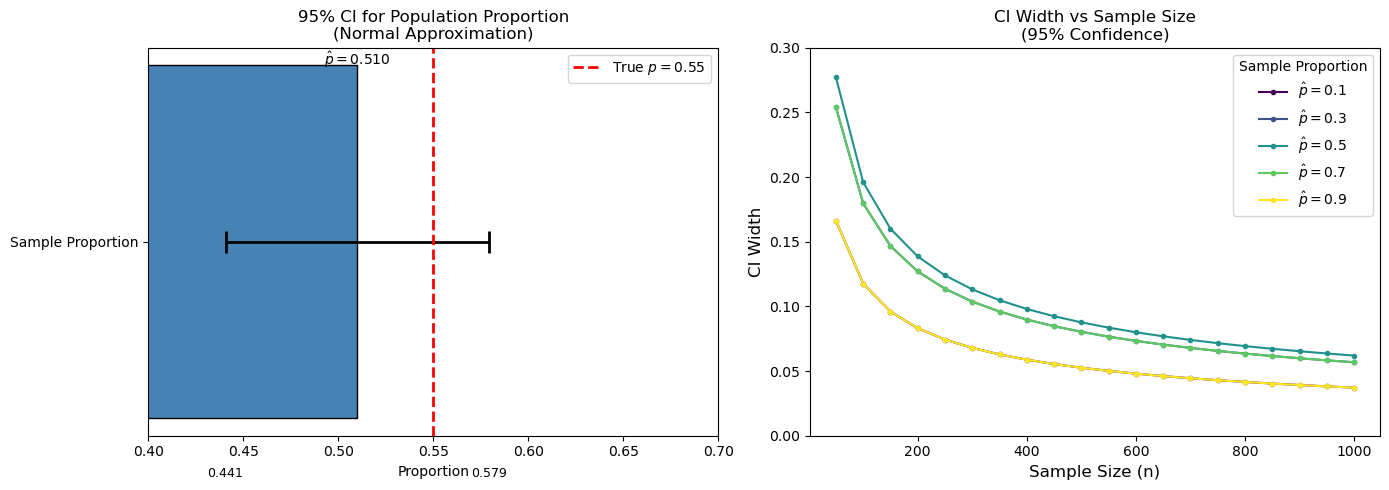

Successes: 102 out of 200
Sample proportion: 0.5100
Normal approx CI: [0.4407, 0.5793]
Wilson CI: [0.4412, 0.5784]


In [5]:
from statsmodels.stats.proportion import proportion_confint

# Simulate polling data
np.random.seed(99)
n_trials = 200
true_p = 0.55
successes = np.random.binomial(n=n_trials, p=true_p)

p_hat = successes / n_trials

# Normal approximation CI
z_crit = stats.norm.ppf(0.975)
se = np.sqrt(p_hat * (1 - p_hat) / n_trials)
ci_norm_lower = p_hat - z_crit * se
ci_norm_upper = p_hat + z_crit * se

# Wilson CI
ci_wilson = proportion_confint(successes, n_trials, alpha=0.05, method='wilson')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Visualize the proportion CI
ax1 = axes[0]
ax1.barh(['Sample Proportion'], [p_hat], color='steelblue', height=0.3, edgecolor='black')
ax1.errorbar(p_hat, 0, xerr=[[p_hat - ci_norm_lower], [ci_norm_upper - p_hat]], 
             fmt='none', color='black', capsize=8, capthick=2, lw=2)
ax1.axvline(true_p, color='red', linestyle='--', lw=2, label=rf'True $p = {true_p}$')
ax1.set_xlim(0.4, 0.7)
ax1.set_xlabel('Proportion')
ax1.set_title('95% CI for Population Proportion\n(Normal Approximation)', fontsize=12)
ax1.legend()

# Add text annotations
ax1.text(p_hat, 0.15, rf'$\hat{{p}} = {p_hat:.3f}$', ha='center', fontsize=10)
ax1.text(ci_norm_lower, -0.2, f'{ci_norm_lower:.3f}', ha='center', fontsize=9)
ax1.text(ci_norm_upper, -0.2, f'{ci_norm_upper:.3f}', ha='center', fontsize=9)

# Plot 2: CI width vs sample size for different p-hats
ax2 = axes[1]
sample_sizes = np.arange(50, 1001, 50)
p_hats_demo = [0.1, 0.3, 0.5, 0.7, 0.9]
colors = plt.cm.viridis(np.linspace(0, 1, len(p_hats_demo)))

for p_demo, color in zip(p_hats_demo, colors):
    widths = []
    for n_demo in sample_sizes:
        se_demo = np.sqrt(p_demo * (1 - p_demo) / n_demo)
        width = 2 * z_crit * se_demo
        widths.append(width)
    ax2.plot(sample_sizes, widths, '-o', color=color, markersize=3, label=rf'$\hat{{p}} = {p_demo}$')

ax2.set_xlabel('Sample Size (n)', fontsize=12)
ax2.set_ylabel('CI Width', fontsize=12)
ax2.set_title('CI Width vs Sample Size\n(95% Confidence)', fontsize=12)
ax2.legend(title='Sample Proportion', loc='upper right')
ax2.set_ylim(0, 0.3)

plt.tight_layout()
plt.savefig('ci_proportion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Successes: {successes} out of {n_trials}")
print(f"Sample proportion: {p_hat:.4f}")
print(f"Normal approx CI: [{ci_norm_lower:.4f}, {ci_norm_upper:.4f}]")
print(f"Wilson CI: [{ci_wilson[0]:.4f}, {ci_wilson[1]:.4f}]")


## 5. Confidence Interval for Variance & Standard Deviation

For normally distributed data, the sample variance follows a **chi-squared distribution**:

$$\frac{(n-1)s^2}{\sigma^2} \sim \chi^2_{n-1}$$

This gives us the CI for variance:

$$\left(\frac{(n-1)s^2}{\chi^2_{\alpha/2, n-1}}, \frac{(n-1)s^2}{\chi^2_{1-\alpha/2, n-1}}\right)$$

And for standard deviation, take the square root of both bounds.

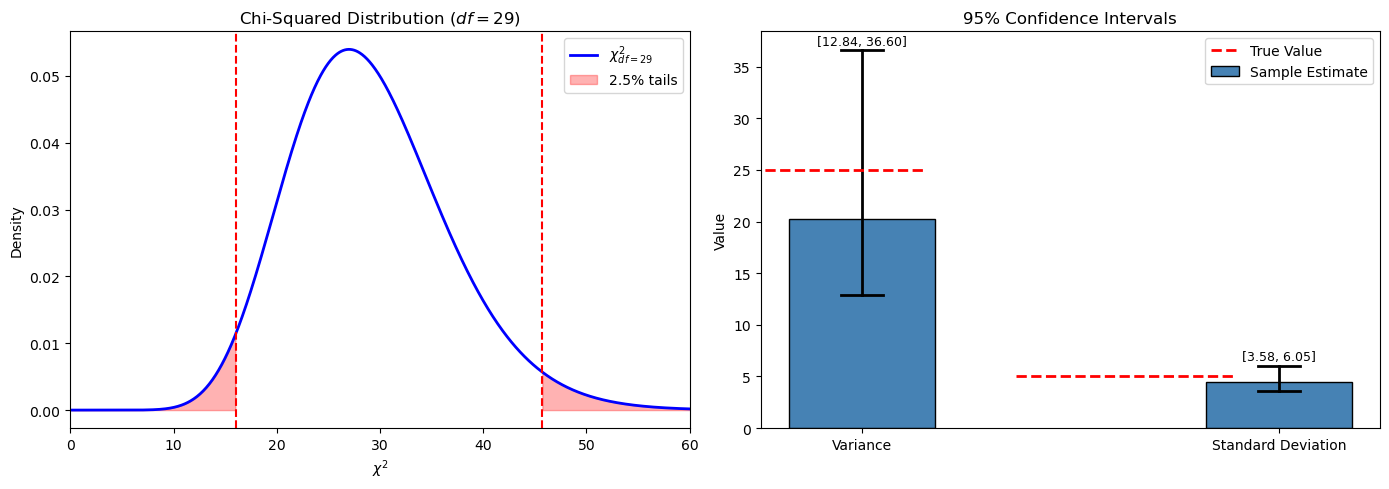

Sample variance: 20.2503
Sample std: 4.5000
95% CI for variance: [12.8440, 36.5960]
95% CI for std: [3.5839, 6.0495]
True variance: 25.0000, True std: 5.0000


In [6]:
# Generate normal data
np.random.seed(42)
n_var = 30
true_sigma = 5
data_var = np.random.normal(loc=0, scale=true_sigma, size=n_var)

sample_var = np.var(data_var, ddof=1)
sample_std = np.std(data_var, ddof=1)

# Chi-squared critical values
chi2_lower = stats.chi2.ppf(0.025, df=n_var-1)
chi2_upper = stats.chi2.ppf(0.975, df=n_var-1)

# CI for variance
ci_var_lower = (n_var - 1) * sample_var / chi2_upper
ci_var_upper = (n_var - 1) * sample_var / chi2_lower

# CI for standard deviation
ci_std_lower = np.sqrt(ci_var_lower)
ci_std_upper = np.sqrt(ci_var_upper)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Chi-squared distribution with shaded area
x_chi2 = np.linspace(0.1, 60, 1000)
chi2_pdf = stats.chi2.pdf(x_chi2, df=n_var-1)

ax1 = axes[0]
ax1.plot(x_chi2, chi2_pdf, 'b-', lw=2, label=rf'$\chi^2_{{df={n_var-1}}}$')

# Shade the tails (rejection regions)
x_left = x_chi2[x_chi2 <= chi2_lower]
x_right = x_chi2[x_chi2 >= chi2_upper]
y_left = stats.chi2.pdf(x_left, df=n_var-1)
y_right = stats.chi2.pdf(x_right, df=n_var-1)

ax1.fill_between(x_left, y_left, alpha=0.3, color='red', label='2.5% tails')
ax1.fill_between(x_right, y_right, alpha=0.3, color='red')

ax1.axvline(chi2_lower, color='red', linestyle='--', lw=1.5)
ax1.axvline(chi2_upper, color='red', linestyle='--', lw=1.5)
ax1.set_title(rf'Chi-Squared Distribution ($df={n_var-1}$)', fontsize=12)
ax1.set_xlabel(r'$\chi^2$')
ax1.set_ylabel('Density')
ax1.legend()
ax1.set_xlim(0, 60)

# Plot 2: Visual comparison of CIs
ax2 = axes[1]
categories = ['Variance', 'Standard Deviation']
true_values = [true_sigma**2, true_sigma]
sample_values = [sample_var, sample_std]
ci_lowers = [ci_var_lower, ci_std_lower]
ci_uppers = [ci_var_upper, ci_std_upper]

x_pos = np.arange(len(categories))
bar_width = 0.35

bars = ax2.bar(x_pos, sample_values, bar_width, color='steelblue', 
               edgecolor='black', label='Sample Estimate')

# Add error bars for CIs
for i, (cat, low, up, true) in enumerate(zip(categories, ci_lowers, ci_uppers, true_values)):
    ax2.plot([i, i], [low, up], 'k-', lw=2)
    ax2.plot([i-0.05, i+0.05], [low, low], 'k-', lw=2)
    ax2.plot([i-0.05, i+0.05], [up, up], 'k-', lw=2)
    ax2.axhline(true, xmin=(i-bar_width/2)/len(categories), xmax=(i+bar_width*1.5)/len(categories),
                color='red', linestyle='--', lw=2, label='True Value' if i == 0 else "")

ax2.set_xticks(x_pos)
ax2.set_xticklabels(categories)
ax2.set_ylabel('Value')
ax2.set_title('95% Confidence Intervals', fontsize=12)
ax2.legend()

# Add text
for i, (low, up, samp) in enumerate(zip(ci_lowers, ci_uppers, sample_values)):
    ax2.text(i, up + 0.5, f'[{low:.2f}, {up:.2f}]', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ci_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sample variance: {sample_var:.4f}")
print(f"Sample std: {sample_std:.4f}")
print(f"95% CI for variance: [{ci_var_lower:.4f}, {ci_var_upper:.4f}]")
print(f"95% CI for std: [{ci_std_lower:.4f}, {ci_std_upper:.4f}]")
print(f"True variance: {true_sigma**2:.4f}, True std: {true_sigma:.4f}")


## 6. Bootstrap Confidence Intervals

When parametric assumptions are questionable or the sampling distribution is unknown, we use **bootstrapping**:

1. Resample the original data **with replacement** many times
2. Calculate the statistic of interest for each resample
3. Use the distribution of bootstrap statistics to construct the CI

### Methods for Bootstrap CIs

| Method | Description |
|--------|-------------|
| **Percentile** | Use $\alpha/2$ and $1-\alpha/2$ percentiles of bootstrap distribution |
| **Basic (Reverse Percentile)** | Adjusts for bias in the estimate |
| **BCa (Bias-Corrected & Accelerated)** | Most accurate, adjusts for skewness |

Bootstrapping is especially powerful for complex statistics (median, correlation, ratio) where theoretical formulas don't exist.

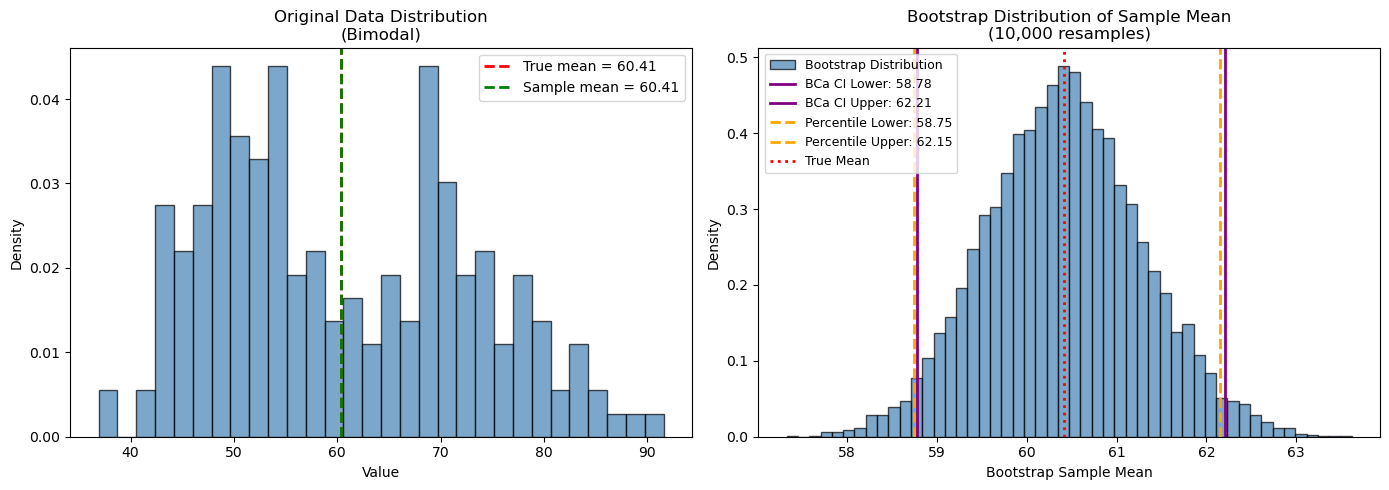

Sample mean: 60.4128
True mean: 60.4128
BCa 95% CI: [58.7812, 62.2087]
Percentile 95% CI: [58.7498, 62.1535]
Standard Error (bootstrap): 0.8681


In [7]:
from scipy.stats import bootstrap

# Generate non-normal data (bimodal)
np.random.seed(2024)
data_a = np.random.normal(loc=50, scale=5, size=100)
data_b = np.random.normal(loc=70, scale=8, size=100)
bootstrap_data = np.concatenate([data_a, data_b])  # Bimodal distribution

# True population mean (known because we generated it)
true_bootstrap_mean = np.mean(bootstrap_data)

# Function for bootstrap
def sample_mean(x, axis=None):
    return np.mean(x, axis=axis)

# Perform bootstrap
rng = np.random.default_rng(42)
res = bootstrap((bootstrap_data,), sample_mean, n_resamples=10000, 
                confidence_level=0.95, random_state=rng, method='BCa')

ci_percentile = np.percentile(res.bootstrap_distribution, [2.5, 97.5])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original data distribution
ax1 = axes[0]
ax1.hist(bootstrap_data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(true_bootstrap_mean, color='red', linestyle='--', lw=2, label=rf'True mean = {true_bootstrap_mean:.2f}')
ax1.axvline(np.mean(bootstrap_data), color='green', linestyle='--', lw=2, label=rf'Sample mean = {np.mean(bootstrap_data):.2f}')
ax1.set_title('Original Data Distribution\n(Bimodal)', fontsize=12)
ax1.set_xlabel('Value')
ax1.set_ylabel('Density')
ax1.legend()

# Plot 2: Bootstrap distribution with CIs
ax2 = axes[1]
ax2.hist(res.bootstrap_distribution, bins=50, density=True, alpha=0.7, 
         color='steelblue', edgecolor='black', label='Bootstrap Distribution')

# Mark CIs
ax2.axvline(res.confidence_interval.low, color='purple', linestyle='-', lw=2, 
            label=f'BCa CI Lower: {res.confidence_interval.low:.2f}')
ax2.axvline(res.confidence_interval.high, color='purple', linestyle='-', lw=2, 
            label=f'BCa CI Upper: {res.confidence_interval.high:.2f}')
ax2.axvline(ci_percentile[0], color='orange', linestyle='--', lw=2, 
            label=f'Percentile Lower: {ci_percentile[0]:.2f}')
ax2.axvline(ci_percentile[1], color='orange', linestyle='--', lw=2, 
            label=f'Percentile Upper: {ci_percentile[1]:.2f}')
ax2.axvline(true_bootstrap_mean, color='red', linestyle=':', lw=2, label='True Mean')

ax2.set_title('Bootstrap Distribution of Sample Mean\n(10,000 resamples)', fontsize=12)
ax2.set_xlabel('Bootstrap Sample Mean')
ax2.set_ylabel('Density')
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('ci_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sample mean: {np.mean(bootstrap_data):.4f}")
print(f"True mean: {true_bootstrap_mean:.4f}")
print(f"BCa 95% CI: [{res.confidence_interval.low:.4f}, {res.confidence_interval.high:.4f}]")
print(f"Percentile 95% CI: [{ci_percentile[0]:.4f}, {ci_percentile[1]:.4f}]")
print(f"Standard Error (bootstrap): {res.standard_error:.4f}")

## 7. Factors Affecting Confidence Interval Width

The width of a confidence interval depends on three things:

1. **Confidence Level**: Higher confidence → wider interval
2. **Sample Size**: Larger $n$ → narrower interval
3. **Variability**: More spread in data → wider interval

$$ \text{Width} = 2 \times z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}} $$

Let's visualize how each factor affects the precision of our estimate.

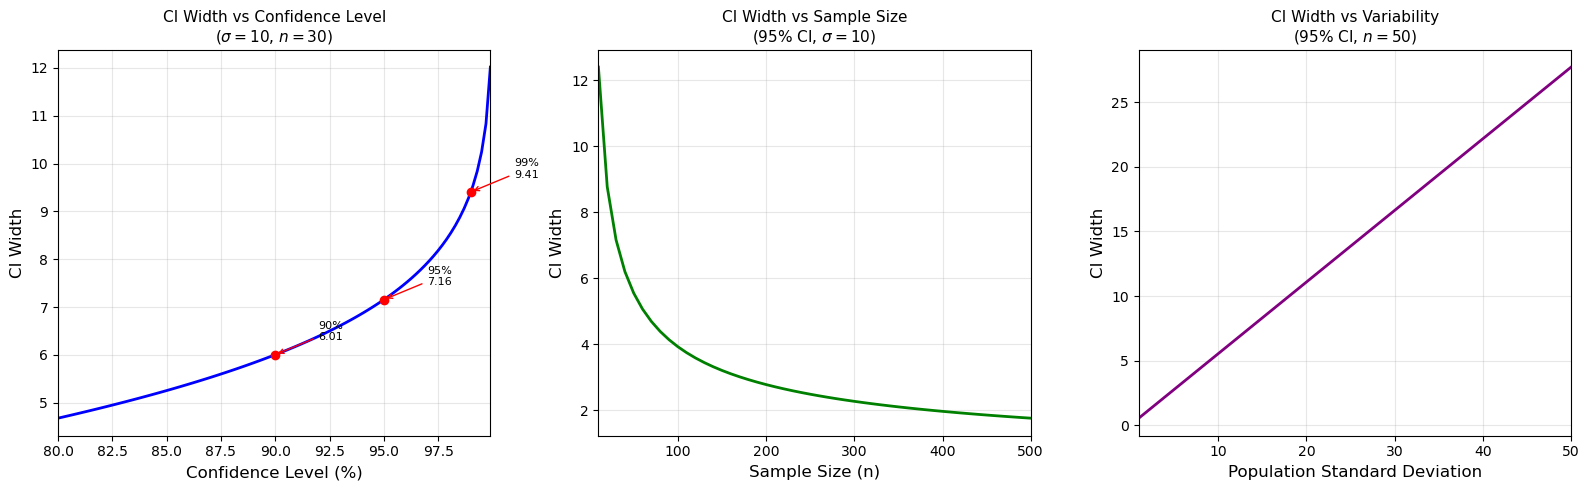

Key Takeaways:
1. To halve the CI width, you need to QUADRUPLE the sample size
2. Higher confidence comes at the cost of precision
3. Reducing variability (e.g., better measurement) tightens CIs


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: CI Width vs Confidence Level
ax1 = axes[0]
confidence_levels = np.linspace(0.80, 0.999, 100)
sigma_fixed = 10
n_fixed = 30

widths_conf = []
for cl in confidence_levels:
    alpha_cl = 1 - cl
    z_cl = stats.norm.ppf(1 - alpha_cl/2)
    width = 2 * z_cl * (sigma_fixed / np.sqrt(n_fixed))
    widths_conf.append(width)

ax1.plot(confidence_levels * 100, widths_conf, 'b-', lw=2)
ax1.set_xlabel('Confidence Level (%)', fontsize=12)
ax1.set_ylabel('CI Width', fontsize=12)
ax1.set_title(rf'CI Width vs Confidence Level' + '\n' + rf'($\sigma={sigma_fixed}$, $n={n_fixed}$)', fontsize=11)
ax1.set_xlim(80, 99.9)
ax1.grid(True, alpha=0.3)

# Mark common levels
for cl_mark in [0.90, 0.95, 0.99]:
    alpha_mark = 1 - cl_mark
    z_mark = stats.norm.ppf(1 - alpha_mark/2)
    w_mark = 2 * z_mark * (sigma_fixed / np.sqrt(n_fixed))
    ax1.plot(cl_mark * 100, w_mark, 'ro', markersize=6)
    ax1.annotate(f'{cl_mark*100:.0f}%\n{w_mark:.2f}', 
                 xy=(cl_mark*100, w_mark), xytext=(cl_mark*100+2, w_mark+0.3),
                 fontsize=8, arrowprops=dict(arrowstyle='->', color='red'))

# Plot 2: CI Width vs Sample Size
ax2 = axes[1]
sample_sizes = np.arange(10, 501, 10)
widths_n = []
for n_val in sample_sizes:
    width = 2 * 1.96 * (sigma_fixed / np.sqrt(n_val))
    widths_n.append(width)

ax2.plot(sample_sizes, widths_n, 'g-', lw=2)
ax2.set_xlabel('Sample Size (n)', fontsize=12)
ax2.set_ylabel('CI Width', fontsize=12)
ax2.set_title(rf'CI Width vs Sample Size' + '\n' + rf'(95% CI, $\sigma={sigma_fixed}$)', fontsize=11)
ax2.set_xlim(10, 500)
ax2.grid(True, alpha=0.3)

# Plot 3: CI Width vs Standard Deviation
ax3 = axes[2]
sigmas = np.linspace(1, 50, 100)
n_fixed_2 = 50
widths_sigma = []
for sig in sigmas:
    width = 2 * 1.96 * (sig / np.sqrt(n_fixed_2))
    widths_sigma.append(width)

ax3.plot(sigmas, widths_sigma, 'purple', lw=2)
ax3.set_xlabel('Population Standard Deviation', fontsize=12)
ax3.set_ylabel('CI Width', fontsize=12)
ax3.set_title(rf'CI Width vs Variability' + '\n' + rf'(95% CI, $n={n_fixed_2}$)', fontsize=11)
ax3.set_xlim(1, 50)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ci_width_factors.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Takeaways:")
print("1. To halve the CI width, you need to QUADRUPLE the sample size")
print("2. Higher confidence comes at the cost of precision")
print("3. Reducing variability (e.g., better measurement) tightens CIs")


## 8. Comparing Two Means: Confidence Interval for the Difference

Often we want to compare two groups (treatment vs control, before vs after).

### Independent Samples (Unequal Variances — Welch's t-test)

$$\text{CI} = (\bar{x}_1 - \bar{x}_2) \pm t_{\alpha/2, df} \cdot \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}$$

where $df$ is approximated by the Welch-Satterthwaite equation.

### Interpretation
If the CI for the difference **does not contain 0**, we conclude there is a statistically significant difference between the groups.

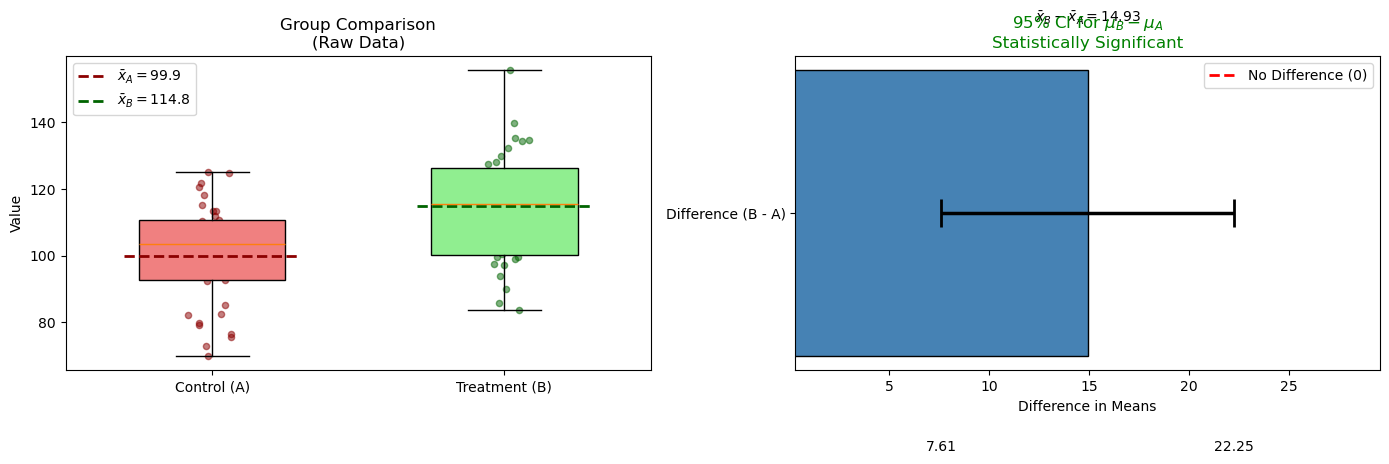

Group A: mean=99.905, std=14.659, n=40
Group B: mean=114.834, std=16.816, n=35
Difference: 14.929
Welch's t-statistic: -4.0705, p-value: 0.0001
Welch df: 68.03
95% CI for difference: [7.610, 22.247]


In [13]:
# Generate two independent samples
np.random.seed(55)
group_a = np.random.normal(loc=100, scale=15, size=40)   # Control
group_b = np.random.normal(loc=112, scale=18, size=35)   # Treatment

# Welch's t-test (unequal variances)
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

# Manual CI calculation
mean_a, mean_b = np.mean(group_a), np.mean(group_b)
std_a, std_b = np.std(group_a, ddof=1), np.std(group_b, ddof=1)
n_a, n_b = len(group_a), len(group_b)

diff_mean = mean_b - mean_a
se_diff = np.sqrt(std_a**2/n_a + std_b**2/n_b)

# Welch-Satterthwaite degrees of freedom
numerator = (std_a**2/n_a + std_b**2/n_b)**2
denominator = (std_a**2/n_a)**2/(n_a-1) + (std_b**2/n_b)**2/(n_b-1)
df_welch = numerator / denominator

t_crit_diff = stats.t.ppf(0.975, df=df_welch)
margin_diff = t_crit_diff * se_diff

ci_diff_lower = diff_mean - margin_diff
ci_diff_upper = diff_mean + margin_diff

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Box plots with individual points
ax1 = axes[0]
bp = ax1.boxplot([group_a, group_b], tick_labels=['Control (A)', 'Treatment (B)'], 
                  patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')

# Add individual points with jitter
np.random.seed(1)
jitter_a = np.random.normal(1, 0.04, size=len(group_a))
jitter_b = np.random.normal(2, 0.04, size=len(group_b))
ax1.scatter(jitter_a, group_a, alpha=0.5, s=20, color='darkred')
ax1.scatter(jitter_b, group_b, alpha=0.5, s=20, color='darkgreen')

ax1.set_ylabel('Value')
ax1.set_title('Group Comparison\n(Raw Data)', fontsize=12)

# Add mean lines
ax1.hlines(mean_a, 0.7, 1.3, colors='darkred', linestyles='--', lw=2, label=rf'$\bar{{x}}_A = {mean_a:.1f}$')
ax1.hlines(mean_b, 1.7, 2.3, colors='darkgreen', linestyles='--', lw=2, label=rf'$\bar{{x}}_B = {mean_b:.1f}$')
ax1.legend(loc='upper left')

# Plot 2: CI for the difference
ax2 = axes[1]
ax2.barh(['Difference (B - A)'], [diff_mean], color='steelblue', height=0.3, edgecolor='black')
ax2.errorbar(diff_mean, 0, xerr=[[diff_mean - ci_diff_lower], [ci_diff_upper - diff_mean]], 
             fmt='none', color='black', capsize=10, capthick=2, lw=2.5)
ax2.axvline(0, color='red', linestyle='--', lw=2, label='No Difference (0)')

# Color based on significance
if ci_diff_lower > 0 or ci_diff_upper < 0:
    sig_text = 'Statistically Significant'
    sig_color = 'green'
else:
    sig_text = 'Not Statistically Significant'
    sig_color = 'orange'

ax2.set_xlim(diff_mean - 2*margin_diff, diff_mean + 2*margin_diff)
ax2.set_xlabel('Difference in Means')
ax2.set_title(rf'95% CI for $\mu_B - \mu_A$' + f'\n{sig_text}', fontsize=12, color=sig_color)
ax2.legend()

# Text annotation
ax2.text(ci_diff_lower, -0.25, f'{ci_diff_lower:.2f}', ha='center', fontsize=10)
ax2.text(ci_diff_upper, -0.25, f'{ci_diff_upper:.2f}', ha='center', fontsize=10)
ax2.text(diff_mean, 0.2, rf'$\bar{{x}}_B - \bar{{x}}_A = {diff_mean:.2f}$', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('ci_two_means.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Group A: mean={mean_a:.3f}, std={std_a:.3f}, n={n_a}")
print(f"Group B: mean={mean_b:.3f}, std={std_b:.3f}, n={n_b}")
print(f"Difference: {diff_mean:.3f}")
print(f"Welch's t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")
print(f"Welch df: {df_welch:.2f}")
print(f"95% CI for difference: [{ci_diff_lower:.3f}, {ci_diff_upper:.3f}]")

## 9. Summary: Choosing the Right Confidence Interval

| Scenario | Formula / Method | Key Assumption |
|----------|-----------------|--------------|
| Mean, $\sigma$ known | $\bar{x} \pm z_{\alpha/2} \cdot \sigma/\sqrt{n}$ | Population normal or $n \geq 30$ |
| Mean, $\sigma$ unknown | $\bar{x} \pm t_{\alpha/2, n-1} \cdot s/\sqrt{n}$ | Population approximately normal |
| Proportion | $\hat{p} \pm z_{\alpha/2}\sqrt{\hat{p}(1-\hat{p})/n}$ | $n\hat{p} \geq 10$, $n(1-\hat{p}) \geq 10$ |
| Variance | $\left(\frac{(n-1)s^2}{\chi^2_{\alpha/2}}, \frac{(n-1)s^2}{\chi^2_{1-\alpha/2}}\right)$ | Population normally distributed |
| Complex statistic | Bootstrap (percentile or BCa) | None (non-parametric) |
| Difference of means | Welch's t-interval | Independent samples |

---

## Key Takeaways

1. **A confidence interval is NOT a probability statement about the parameter.** The parameter is fixed; the interval is random. We are 95% confident in the *method*, not any single interval.

2. **Width trade-off:** You can have high confidence or high precision, but not both without more data.

3. **The t-distribution protects you** when $\sigma$ is unknown and $n$ is small. Always use t for small samples.

4. **Bootstrapping is your friend** when theory fails or assumptions are violated.

5. **Never say "there is a 95% probability that $\mu$ is in this interval."** Say "this interval was produced by a method that captures $\mu$ 95% of the time."

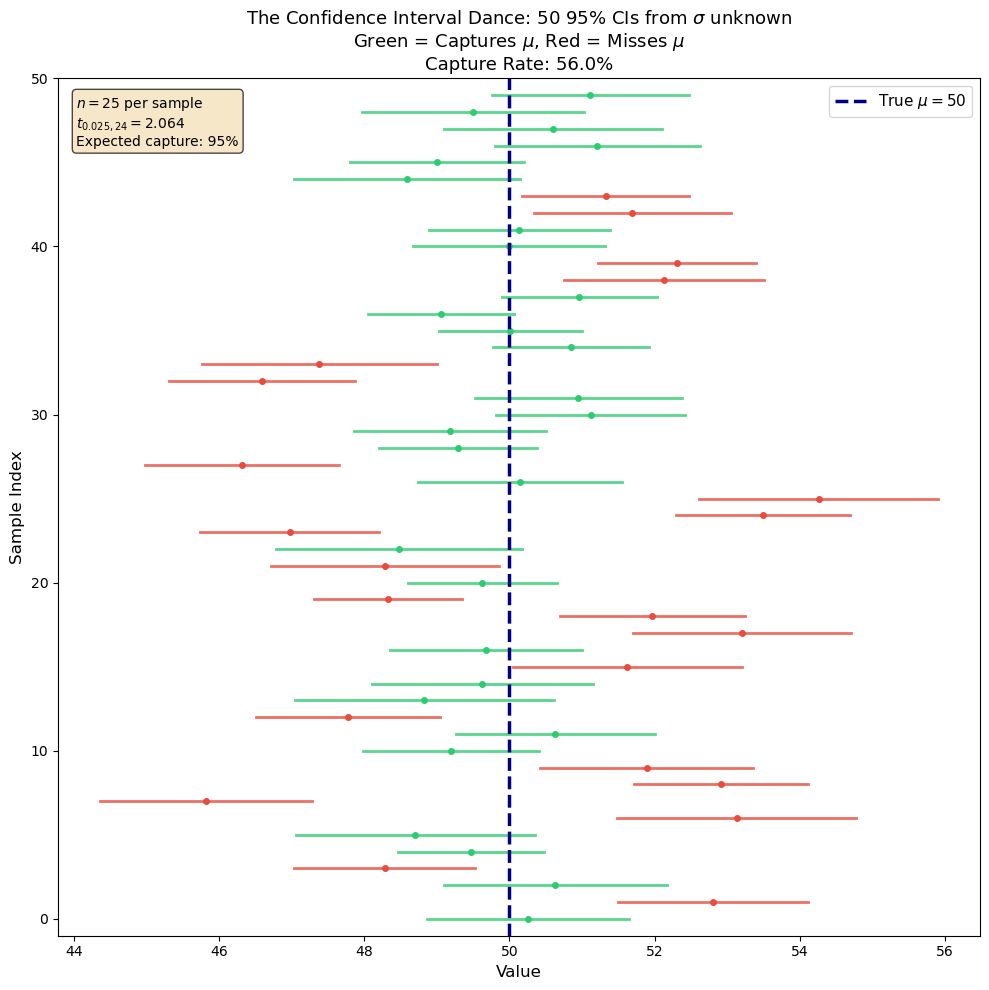

NOTEBOOK COMPLETE
Generated visualizations:
  1. sampling_distribution.png
  2. ci_mean_sigma_known.png
  3. t_vs_z_distribution.png
  4. ci_proportion.png
  5. ci_variance.png
  6. ci_bootstrap.png
  7. ci_width_factors.png
  8. ci_two_means.png
  9. ci_dance.png


In [10]:
# Final summary visualization: The "Confidence Interval Dance"
# Shows how intervals vary across repeated sampling

np.random.seed(999)
mu_dance = 50
sigma_dance = 10
n_dance = 25
n_intervals = 50

sample_means_dance = np.random.normal(mu_dance, sigma_dance/np.sqrt(n_dance), n_intervals)
sample_stds_dance = np.random.chisquare(df=n_dance-1, size=n_intervals) / (n_dance-1) * sigma_dance
sample_stds_dance = np.sqrt(sample_stds_dance)

t_crit_dance = stats.t.ppf(0.975, df=n_dance-1)
margins_dance = t_crit_dance * (sample_stds_dance / np.sqrt(n_dance))

lower_dance = sample_means_dance - margins_dance
upper_dance = sample_means_dance + margins_dance
captures_dance = (lower_dance <= mu_dance) & (upper_dance >= mu_dance)

fig, ax = plt.subplots(figsize=(10, 10))

for i in range(n_intervals):
    color = '#2ecc71' if captures_dance[i] else '#e74c3c'
    ax.plot([lower_dance[i], upper_dance[i]], [i, i], color=color, alpha=0.8, lw=2)
    ax.plot(sample_means_dance[i], i, 'o', color=color, markersize=4)

ax.axvline(mu_dance, color='navy', linestyle='--', lw=2.5, label=rf'True $\mu = {mu_dance}$')

# Title and labels
ax.set_title(rf'The Confidence Interval Dance: {n_intervals} 95% CIs from $\sigma$ unknown' + '\n' +
             rf'Green = Captures $\mu$, Red = Misses $\mu$' + '\n' +
             rf'Capture Rate: {np.mean(captures_dance)*100:.1f}%', fontsize=13)

ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Sample Index', fontsize=12)
ax.set_ylim(-1, n_intervals)
ax.legend(loc='upper right', fontsize=11)

# Add annotation box
textstr = (rf'$n = {n_dance}$ per sample' + '\n'
           rf'$t_{{0.025, {n_dance-1}}} = {t_crit_dance:.3f}$' + '\n'
           rf'Expected capture: 95%')
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('ci_dance.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("NOTEBOOK COMPLETE")
print("=" * 50)
print("Generated visualizations:")
print("  1. sampling_distribution.png")
print("  2. ci_mean_sigma_known.png")
print("  3. t_vs_z_distribution.png")
print("  4. ci_proportion.png")
print("  5. ci_variance.png")
print("  6. ci_bootstrap.png")
print("  7. ci_width_factors.png")
print("  8. ci_two_means.png")
print("  9. ci_dance.png")